In [154]:
import yfinance as yf

In [155]:
import numpy as np

In [156]:
import pandas as pd

In [157]:
import matplotlib.pyplot as plt

# Function get_financials is needed to get EBITDA (free cash flow)

In [158]:
def get_financials(ticker):
    try:
        stock = yf.Ticker(ticker)

        pnl = stock.financials  # Income Statement
        bs = stock.balance_sheet  # Balance Sheet
        cf = stock.cashflow  # Cash Flow Statement

        # Concatenate financials into one DataFrame
        fs = pd.concat([pnl, bs, cf])

        if fs.empty:
            return None

        # Replace NaN values with None for better JSON serialization
        fs = fs.replace({np.nan: None})

        # Transpose data so that items are rows and dates are columns
        fs_transposed = fs.T
        fs_transposed['Ticker'] = ticker
        fs_transposed.reset_index(inplace=True)
        fs_transposed.rename(columns={'index': 'Date'}, inplace=True)
        fs_transposed['Date'] = pd.to_datetime(fs_transposed['Date']).dt.year

        # Sort the data by Date and then limit it to the latest 4 years
        fs_transposed = fs_transposed.sort_values(by='Date', ascending=False).head(4)  # Limiting to 4 years

        return fs_transposed

    except Exception as e:
        print(f"Error fetching financials for {ticker}: {e}")
        return None


# Function get_company_financials calls get_financials 

In [159]:
def get_company_financials(ticker):
    if not ticker:
        print("No ticker provided")
        return

    try:
        financial_data = get_financials(ticker)
        if financial_data is None or financial_data.empty:
            print(f"No financial data found for the given ticker: {ticker}")
            return

        # Set pandas to display all columns or a limited number of columns
        pd.set_option('display.max_columns', 20)  # Set to 20 columns (adjust as needed)
        
        # Print the financial data
        # print(financial_data)
        return financial_data

    except Exception as e:
        print(f"Failed to fetch stock data: {str(e)}")

## User inputs are ticker, years, terminal_growth (terminal growth rate)

In [160]:
ticker = "NVDA"

In [161]:
years = 3

In [162]:
terminal_growth = 0.025

In [163]:
financial_data = get_company_financials(ticker)

# Let's assume the growth rate for the years up to the terminal year is the most current growth rate

In [164]:
current_growth_rate = (financial_data ["EBITDA"].iloc[0] / financial_data ["EBITDA"].iloc[1]) - 1

In [165]:
print(f"Current growth rate is estimated to be {current_growth_rate}")

Current growth rate is estimated to be 1.4207346204648288


In [166]:
print(  financial_data [["Date", "EBITDA"]] )

   Date         EBITDA
0  2025  86137000000.0
1  2024  35583000000.0
2  2023   5986000000.0
3  2022  11351000000.0


[Text(0, 0, '2025'),
 Text(1, 0, '2024'),
 Text(2, 0, '2023'),
 Text(3, 0, '2022')]

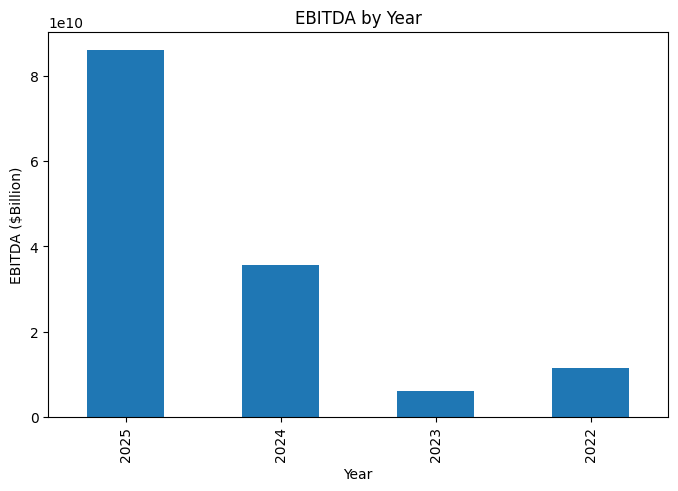

In [167]:


plt.figure(figsize=(8, 5))
fig = financial_data["EBITDA"].plot(kind='bar')
fig.set_title('EBITDA by Year')
fig.set_xlabel('Year')
fig.set_ylabel('EBITDA ($Billion)')
fig.set_xticklabels(financial_data["Date"])



In [168]:
def dcf_valuation(fcf, shares_outstanding, growth_rate=0.05, discount_rate=0.10, terminal_growth=0.02, years=5):
    """
    Performs a simple DCF valuation.
    """
    try:
        # Use the most recent FCF as base
        latest_fcf = fcf
        if latest_fcf <= 0:
            raise ValueError("Latest FCF is non-positive, DCF may not be meaningful.")

        # Project FCF for given years
        projected_fcfs = [latest_fcf * ((1 + growth_rate) ** year) for year in range(1, years + 1)]

        # Discount projected FCFs to present value
        discounted_fcfs = [fcf / ((1 + discount_rate) ** year) for year, fcf in enumerate(projected_fcfs, start=1)]

        # Terminal value using Gordon Growth Model
        terminal_value = (projected_fcfs[-1] * (1 + terminal_growth)) / (discount_rate - terminal_growth)
        discounted_terminal_value = terminal_value / ((1 + discount_rate) ** years)

        # Enterprise value
        enterprise_value = sum(discounted_fcfs) + discounted_terminal_value

        # Intrinsic value per share
        intrinsic_value_per_share = enterprise_value / shares_outstanding

        return intrinsic_value_per_share

    except Exception as e:
        print(f"Error in DCF calculation: {e}")
        return None




In [170]:
financial_data = get_company_financials(ticker)

In [171]:
print(  financial_data [["Date", "EBITDA"]] )

   Date         EBITDA
0  2025  86137000000.0
1  2024  35583000000.0
2  2023   5986000000.0
3  2022  11351000000.0


In [172]:
fcf = financial_data ["EBITDA"].iloc[0]

In [173]:
print (fcf)

86137000000.0


In [174]:
stock = yf.Ticker(ticker)

In [175]:
print (stock)

yfinance.Ticker object <NVDA>


In [176]:
 shares = getattr(ticker, "fast_info", {}).get("shares_outstanding", None)


In [177]:
dict = stock.get_info()

In [178]:
shares =  (dict['sharesOutstanding'])

In [179]:
print (shares)

24305000000


In [180]:
growth_rate = current_growth_rate

In [181]:
beta = stock.info['beta']

In [182]:
discount_rate = abs(beta) * 0.10

In [193]:
print (round(discount_rate, 4))

0.2314


In [194]:
print (beta)

2.314


In [189]:
intrinsic_value = round( dcf_valuation(fcf, shares, growth_rate, discount_rate, terminal_growth, years) , 2)

In [190]:
print (fcf)
print (shares)
print (fcf / shares)

86137000000.0
24305000000
3.544003291503806


In [191]:
print (intrinsic_value)

181.29


In [188]:
current_price = stock.info['currentPrice']

In [153]:
print (current_price)

190.05
